## Reference notebook

This notebook is based on the official/sample Mega Lucario ex rule-based agent notebook:

- [A Sample Rule-Based Agent: Mega Lucario ex Deck](https://www.kaggle.com/code/kiyotah/a-sample-rule-based-agent-mega-lucario-ex-deck/notebook)

The core implementation is mostly unchanged.  
My main contribution in this notebook is to add beginner-friendly explanations about:

- how the deck is represented
- how `deck.csv` is created or read
- how files under `/kaggle/input` and `/kaggle/working` are used
- how `submission.tar.gz` is built
- how to submit safely from Kaggle Notebooks

# [Beginner Guide] From Deck to First Valid Submission

This notebook is a beginner guide for **The Pokémon Company - PTCG AI Battle Challenge Simulation**.

The goal is not to build the strongest agent. The goal is simpler:

**Create a valid `submission.tar.gz` and understand what files are involved.**

Once your first valid submission works, you can start improving the deck, the rule-based policy, self-play evaluation, reinforcement learning, or MCTS.


## Deck image

The original sample notebook shows the Mega Lucario ex deck visually. We keep that here because it is easier to understand the deck before looking at Card IDs.

![Deck](https://ptcgvis.heroz.jp/img/pnlksjwueblpgmez/hbpnvivyrpqpnbc.png)


## What this notebook explains

This competition is a **simulation competition**.

In many Kaggle competitions, you read `train.csv` and `test.csv` from `/kaggle/input`, train a model, and submit `submission.csv`.

This competition is different. We submit an **agent bundle**. In this notebook, `/kaggle/input` is mostly used as a source of files needed to build that bundle, such as sample submission files, card data, and optionally a `deck.csv`.

The final output is:

```text
submission.tar.gz
```

For this notebook, the important idea is:

```text
Read existing files from /kaggle/input
Create submission files under /kaggle/working
Submit submission.tar.gz
```


## The Kaggle Notebook screen

The right sidebar is important.

It shows:

- **Input**: files available from `/kaggle/input`
- **Output**: files generated under `/kaggle/working`
- **Submit to competition**: a shortcut for submitting from the editor

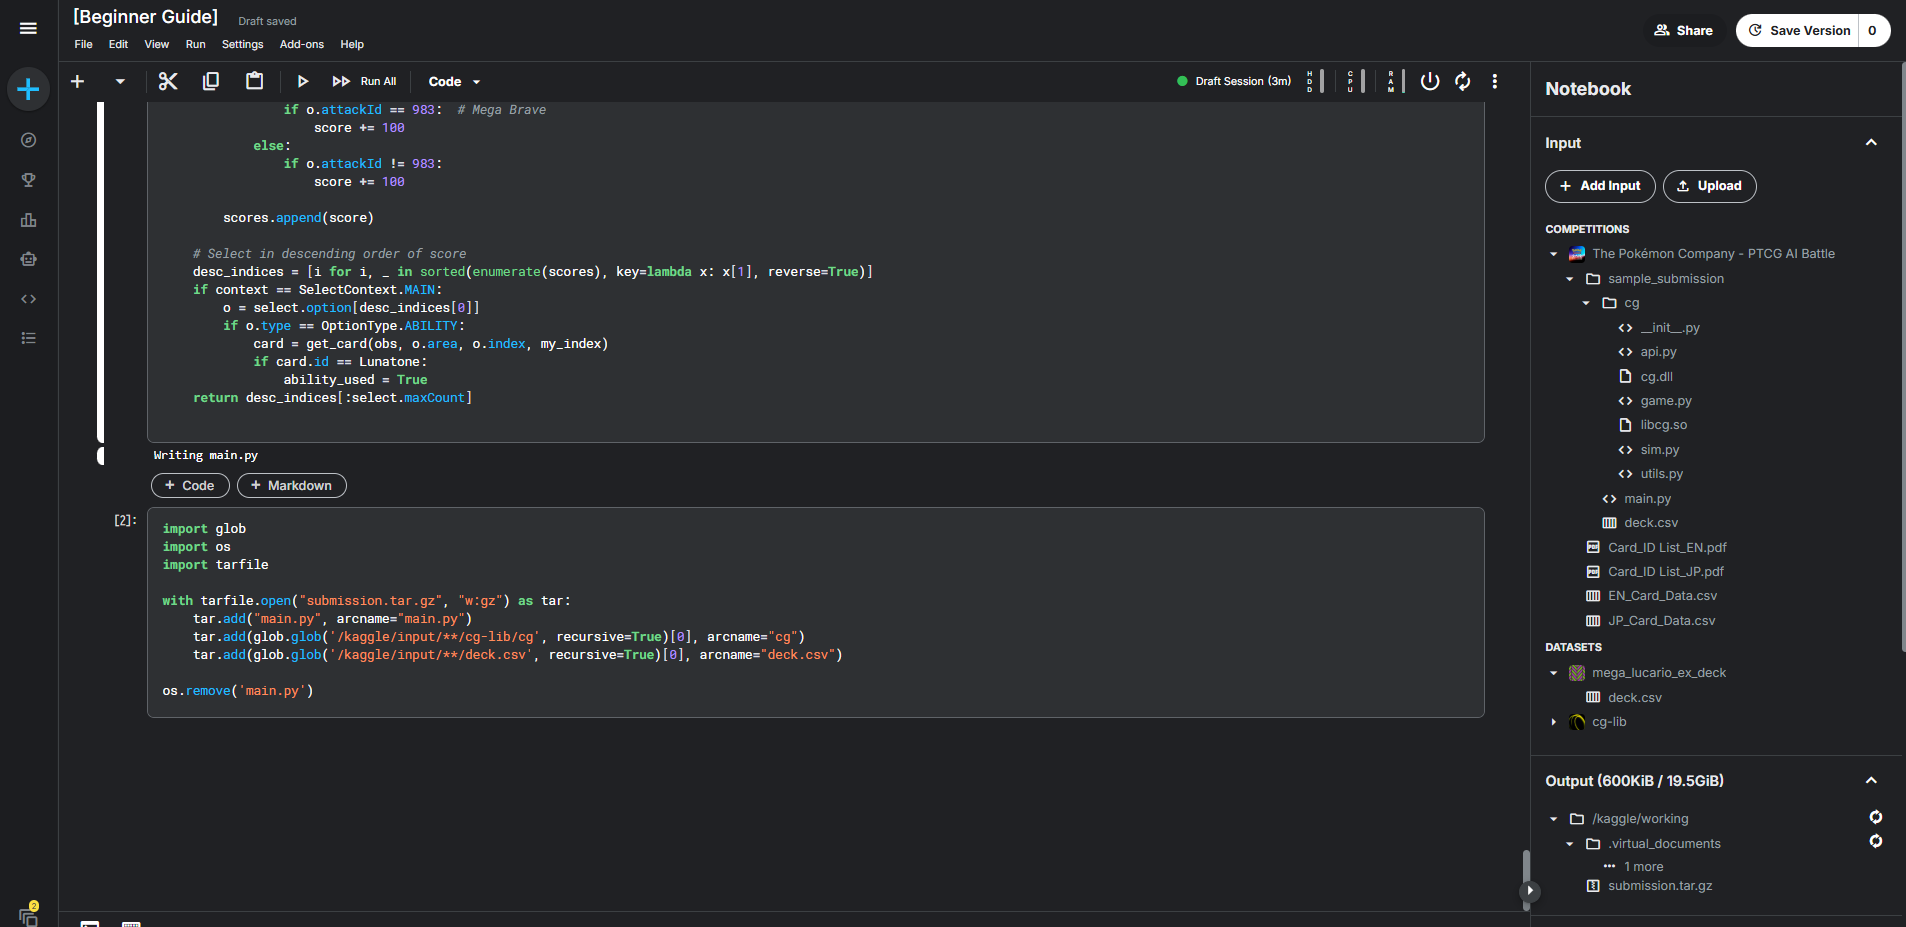

In the screenshot, `submission.tar.gz` appears in the Output section. That is the file we want to submit.


## Deck setup: easiest option first

For the first submission, the easiest option is to hardcode the 60 Card IDs in the notebook and write them to `deck.csv`.

This avoids extra setup around Kaggle Datasets.

You can also read an existing deck file from:

```text
/kaggle/input/datasets/kiyotah/mega-lucario-ex-deck/deck.csv
```

Both approaches are valid. This notebook defaults to the hardcoded deck because it is easier for a first valid submission.

Later, when you test many decks, keeping decks as separate `deck.csv` files becomes more convenient.


In [1]:
import os
from pathlib import Path

USE_EXTERNAL_DECK_CSV = False

EXTERNAL_DECK_CANDIDATES = [
    "/kaggle/input/datasets/kiyotah/mega-lucario-ex-deck/deck.csv",
    "/kaggle/input/mega-lucario-ex-deck/deck.csv",
]

HARD_CODED_DECK = [
    673, 673, 674, 674, 675, 675, 676, 676,
    676, 677, 677, 677, 678, 678, 678, 678,
    1102, 1102, 1102, 1102, 1123, 1123, 1141, 1141,
    1141, 1141, 1142, 1142, 1142, 1142, 1152, 1152,
    1152, 1152, 1159, 1182, 1182, 1192, 1192, 1192,
    1192, 1227, 1227, 1227, 1227, 1252, 1252, 6,
    6, 6, 6, 6, 6, 6, 6, 6,
    6, 6, 6, 6,
]

if USE_EXTERNAL_DECK_CSV:
    deck_path = next((p for p in EXTERNAL_DECK_CANDIDATES if os.path.exists(p)), None)
    if deck_path is None:
        raise FileNotFoundError(
            "No external deck.csv was found. Set USE_EXTERNAL_DECK_CSV = False or add the dataset input."
        )
    with open(deck_path, "r") as f:
        deck = [int(x) for x in f.read().splitlines() if x.strip()]
    deck_source = deck_path
else:
    deck = HARD_CODED_DECK
    deck_source = "HARD_CODED_DECK"

if len(deck) != 60:
    raise ValueError(f"A deck must contain exactly 60 cards, but got {len(deck)} cards.")

with open("deck.csv", "w") as f:
    for card_id in deck:
        f.write(f"{card_id}\n")

print("Deck source:", deck_source)
print("Deck size:", len(deck))
print("First 10 Card IDs:", deck[:10])
print("deck.csv written to:", Path("deck.csv").resolve())

Deck source: HARD_CODED_DECK
Deck size: 60
First 10 Card IDs: [673, 673, 674, 674, 675, 675, 676, 676, 676, 677]
deck.csv written to: /kaggle/working/deck.csv


## What is `deck.csv`?

`deck.csv` is just a 60-line list of Card IDs.

Each line represents one card in the deck.

It is not a list of card names.

The sample agent reads `deck.csv` at the start of the game. When the simulator first asks for the deck, the agent returns this 60-card list.


In [2]:
with open("deck.csv", "r") as f:
    deck_lines = f.read().splitlines()

print("Number of lines in deck.csv:", len(deck_lines))
print("First 10 lines:")
for line in deck_lines[:10]:
    print(line)


Number of lines in deck.csv: 60
First 10 lines:
673
673
674
674
675
675
676
676
676
677


## Two kinds of hardcoding in the sample agent

There are two different things in the code:

1. **The actual 60-card deck**
2. **Card ID constants used by the rule-based policy**

The original sample agent already hardcodes many Card IDs for its rule-based logic, such as `Mega_Lucario_ex = 678`.

That does not mean the 60-card deck must also be hardcoded. The 60-card deck can come from `deck.csv`, or it can be written directly as a Python list.

For a first submission, hardcoding the deck list is fine. For repeated deck experiments, `deck.csv` is easier to manage.


## Write `main.py`

The next cell writes the agent code to `main.py`.

This is the main entry point of the submitted agent.

The code below is based on the Mega Lucario ex rule-based sample agent. It still reads `deck.csv`, so the `deck.csv` file created above will be included in the final `submission.tar.gz`.


In [3]:
%%writefile main.py
import os
import sys
from collections import defaultdict

from cg.api import AreaType, CardType, EnergyType, Observation, SelectContext, OptionType, Card, Pokemon, all_card_data, to_observation_class

"""
Mega Lucario ex Deck
Intermediate Level
This deck battles by strategically switching between Mega Lucario ex as the main attacker, and Hariyama and Solrock as secondary attackers.
"""

# Load deck.csv in the dataset
file_path = "deck.csv"
if not os.path.exists(file_path):
    file_path = "/kaggle_simulations/agent/" + file_path
with open(file_path, "r") as file:
    csv = file.read().split("\n")
my_deck = []
for i in range(60):
    my_deck.append(int(csv[i]))

# Fetch card metadata database and create an ID-to-Card lookup table
all_card = all_card_data()
card_table = {c.cardId:c for c in all_card}

# Decklist
Makuhita = 673  # ×2
Hariyama = 674  # ×2
Lunatone = 675  # ×2
Solrock = 676  # ×3
Riolu = 677  # ×3
Mega_Lucario_ex = 678  # ×4
Dusk_Ball = 1102  # ×4
Switch = 1123  # ×2
Premium_Power_Pro = 1141  # ×4
Fighting_Gong = 1142  # ×4
Poke_Pad = 1152  # x4
Hero_Cape = 1159  # ×1
Boss_Orders = 1182  # ×2
Carmine = 1192  # ×4
Lillie_Determination = 1227  # ×4
Gravity_Mountain = 1252  # ×2
Basic_Fighting_Energy = 6  # ×13


class AttackPlan:
    attacker = -1
    target = -1
    attack_index = -1
    remain_hp = -1
    energy = False


plan = AttackPlan()
pre_turn = 0
ability_used = False


def get_card(obs: Observation, area: AreaType, index: int, player_index: int) -> Pokemon | Card | None:
    """Helper function to safely extract a Card or Pokemon object from specific zones."""
    ps = obs.current.players[player_index]
    match area:
        case AreaType.DECK:
            return obs.select.deck[index]
        case AreaType.HAND:
            return ps.hand[index]
        case AreaType.DISCARD:
            return ps.discard[index]
        case AreaType.ACTIVE:
            return ps.active[index]
        case AreaType.BENCH:
            return ps.bench[index]
        case AreaType.PRIZE:
            return ps.prize[index]
        case AreaType.STADIUM:
            return obs.current.stadium[index]
        case AreaType.LOOKING:
            return obs.current.looking[index]
        case _:
            return None


def prize_count(pokemon: Pokemon) -> int:
    """Calculates how many Prize cards a Pokémon yields upon being Knocked Out, factoring in modifiers."""
    data = card_table[pokemon.id]
    count = 3 if data.megaEx else 2 if data.ex else 1
    for card in pokemon.energyCards:
        if card.id == 12:  # Legacy Energy
            count -= 1
    for card in pokemon.tools:
        if card.id == 1172 and "Lillie" in data.name:  # Lillie’s Pearl
            count -= 1
    return max(0, count)


def pokemon_score(pokemon: Pokemon) -> int:
    """Heuristically evaluates the tactical worth of targeting a specific Pokémon on the opponent's field."""
    data = card_table[pokemon.id]
    score = prize_count(pokemon) * 1000
    score += len(pokemon.energies) * 150
    score += len(pokemon.tools) * 100
    if data.stage2:
        score += 250
    elif data.stage1:
        score += 130
    
    id = pokemon.id
    # Squawkabilly ex, Noctowl, Fan Rotom, Archaludon ex
    if id == 144 or id == 322 or id == 323 or id == 337:
        score -= 200
    if id == 112 and len(pokemon.energies) >= 1:  # Munkidori
        score += 300
    score += pokemon.hp
    return score


def agent(obs_dict: dict) -> list[int]:
    """Main Agent Function.

    Each element in the returned list must be >= 0 and < len(obs.select.option).
    The list length must be between obs.select.minCount and obs.select.maxCount (inclusive), with no duplicate elements.
    
    Returns:
        list[int]: A list of option index.
    """
    obs = to_observation_class(obs_dict)
    if obs.select == None:
        # In the initial selection, the obs.select is None, and it is necessary to return the deck.
        # The deck is a list of 60 card IDs.
        # The deck must comply with the Pokémon Trading Card Game rules.
        return my_deck
        
    state = obs.current
    select = obs.select
    context = select.context
    my_index = state.yourIndex
    my_state = state.players[my_index]
    op_state = state.players[1 - my_index]
    my_prize = len(my_state.prize)

    global plan
    global pre_turn
    global ability_used
    if pre_turn != state.turn:
        pre_turn = state.turn
        plan = AttackPlan()
        ability_used = False
            
    field_counts = defaultdict(int)  # Number of cards per card ID on the Bench and in the Active Spot
    hand_counts = defaultdict(int)  # Number of cards per card ID in hand
    discard_counts = defaultdict(int)  # Number of cards per card ID in discard pile

    attacker1 = False
    attacker2 = False
    for card in my_state.active + my_state.bench:
        if card == None:
            continue
        field_counts[card.id] += 1
        if card.id == Makuhita or card.id == Hariyama:
            if len(card.energies) >= 3:
                attacker2 = True
        elif card.id == Riolu or card.id == Mega_Lucario_ex:
            if len(card.energies) >= 2:
                attacker1 = True

    for card in my_state.hand:
        hand_counts[card.id] += 1

    for card in my_state.discard:
        discard_counts[card.id] += 1

    stadium_id = 0
    for card in state.stadium:
        stadium_id = card.id
            
    can_attack = False
    if context == SelectContext.MAIN:
        can_switch = False
        can_op_switch = False
        can_use_mega_brave = False
        for o in select.option:
            if o.type == OptionType.PLAY:
                card = get_card(obs, AreaType.HAND, o.index, my_index)
                if card.id == Switch:
                    can_switch = True
                elif card.id == Boss_Orders:
                    can_op_switch = True
            elif o.type == OptionType.EVOLVE:
                card = get_card(obs, AreaType.HAND, o.index, my_index)
                if card.id == Hariyama:
                    can_op_switch = True
            elif o.type == OptionType.RETREAT:
                can_switch = True
            elif o.type == OptionType.ATTACK:
                can_attack = True
                if o.attackId == 983:  # Mega Brave
                    can_use_mega_brave = True
        
        my_cards = [my_state.active[0]]
        for pokemon in my_state.bench:
            my_cards.append(pokemon)
        op_cards = [op_state.active[0]]
        for pokemon in op_state.bench:
            op_cards.append(pokemon)

        if state.turn >= 2:
            best_score = -1
            for i, my_pokemon in enumerate(my_cards):
                if i != 0 and not can_switch:
                    break
                for a in range(2):
                    energy_required = 0
                    base_damage = 0
                    base_score = 0
                    if my_pokemon.id == Mega_Lucario_ex:
                        if a == 0:
                            energy_required = 1
                            base_damage = 130
                            base_score += 60 * min(3, discard_counts[Basic_Fighting_Energy])
                        else:
                            energy_required = 2
                            base_damage = 270
                        if my_prize == 2 or my_prize == 3:
                            base_score -= 500
                    elif a == 1:
                        break
                    elif my_pokemon.id == Hariyama:
                        energy_required = 3
                        base_damage = 210
                    elif my_pokemon.id == Makuhita:
                        for o in select.option:
                            if o.type == OptionType.EVOLVE:
                                index = o.inPlayIndex
                                if o.inPlayArea == AreaType.BENCH:
                                    index += 1
                                if index == i:
                                    break
                        else:
                            break
                        base_score -= 100
                        energy_required = 3
                        base_damage = 210
                    elif my_pokemon.id == Solrock:
                        if field_counts[Lunatone] >= 1:
                            energy_required = 1
                            base_damage = 70
                    
                    if base_damage <= 0:
                        continue
                    
                    more_energy = False
                    energy_count = len(my_pokemon.energies)
                    if a == 1 and i == 0 and energy_count >= 2 and not can_use_mega_brave:
                        break
                    if energy_count < energy_required:
                        if hand_counts[Basic_Fighting_Energy] >= 1 and not state.energyAttached:
                            energy_count += 1
                            if energy_count < energy_required:
                                continue
                            else:
                                more_energy = True
                        else:
                            continue

                    for j, op_pokemon in enumerate(op_cards):
                        if j != 0 and not can_op_switch:
                            break
                        damage = base_damage
                        data = card_table[op_pokemon.id]
                        if data.weakness == EnergyType.FIGHTING:
                            damage *= 2
                        elif data.resistance == EnergyType.FIGHTING:
                            damage -= 30
                        prize = 0
                        score = pokemon_score(op_pokemon)
                        if op_pokemon.hp <= damage:
                            prize = prize_count(op_pokemon)
                        else:
                            score *= damage / op_pokemon.hp
                        score += base_score
                            
                        if len(op_state.prize) <= prize:
                            score = 50000
                        
                        if i == 0:
                            score += 220
                        if j == 0:
                            score += 300
                        score += energy_count
                        if best_score < score:
                            best_score = score
                            plan.attacker = i
                            plan.target = j
                            plan.attack_index = a
                            plan.remain_hp = op_pokemon.hp - damage
                            plan.energy = more_energy
    
    # Attach energy score
    def energy_score(pokemon: Pokemon, active: bool) -> int:
        energy_count = len(pokemon.energies)
        score = 8000
        if active:
            score += 10
        if pokemon.id == Makuhita or pokemon.id == Hariyama:
            if pokemon.id == Hariyama:
                score += 1
            if energy_count < 3:
                score += 100
            if attacker2:
                score -= 50
        elif pokemon.id == Lunatone:
            score -= 100
        elif pokemon.id == Solrock:
            if energy_count < 1:
                score += 20
            else:
                score -= 100
        elif pokemon.id == Riolu or pokemon.id == Mega_Lucario_ex:
            if pokemon.id == Mega_Lucario_ex:
                score += 1
            if energy_count < 2:
                score += 100
            if attacker1:
                score -= 50
        return score

    # Iterate over every possible option and assign a heuristic score.
    scores = []  # Score for each action
    for o in select.option:
        score = 0  # The default and baseline score is 0.
        if o.type == OptionType.NUMBER:
            score = o.number  # e.g., for "draw X cards"
        elif o.type == OptionType.YES:
            score = 1  # Prefer "Yes"
        elif o.type == OptionType.CARD:
            card = get_card(obs, o.area, o.index, o.playerIndex)
            if card != None:
                energy_count = 0
                if isinstance(card, Pokemon):
                    energy_count = len(card.energies)
                if context == SelectContext.SWITCH or context == SelectContext.TO_ACTIVE:
                    # Selection of the Pokémon to send to the Active Spot
                    if o.playerIndex == my_index:
                        score += energy_count * 2
                        if o.index == plan.attacker - 1:
                            score += 100
                        if card.id == Mega_Lucario_ex:
                            if my_prize == 2 or my_prize == 3:
                                score += 8
                            else:
                                score += 20
                        elif card.id == Hariyama and energy_count >= 2:
                            score += 15
                        elif card.id == Makuhita and energy_count >= 2:
                            score += 10
                        elif card.id == Solrock:
                            score += 5
                        elif card.id == Riolu:
                            score += 4
                    else:
                        if o.index == plan.target - 1:
                            score += 100
                elif context == SelectContext.SETUP_ACTIVE_POKEMON:
                    # Prioritize playing Riolu if going first, and Solrock if going second.
                    if card.id == Solrock:
                        if state.firstPlayer == my_index:
                            score = 2
                        else:
                            score = 4
                    elif card.id == Riolu:
                        score = 3
                    elif card.id == Makuhita:
                        score = 1
                elif context == SelectContext.TO_HAND:
                    score = 200 - hand_counts[card.id] * 100
                    if card.id == Makuhita:
                        if field_counts[card.id] >= 1:
                            score -= 10
                        else:
                            score += 10
                    elif card.id == Hariyama:
                        if field_counts[Makuhita] >= 1:
                            score += 20
                        else:
                            score -= 20
                    elif card.id == Lunatone:
                        if field_counts[card.id] >= 1:
                            score -= 250
                        else:
                            score += 60
                    elif card.id == Solrock:
                        if field_counts[card.id] >= 1:
                            score -= 250
                        else:
                            score += 50
                    elif card.id == Riolu:
                        if field_counts[card.id] + field_counts[Mega_Lucario_ex] >= 2:
                            score -= 150
                        elif field_counts[card.id] + field_counts[Mega_Lucario_ex] >= 1:
                            score -= 3
                        else:
                            score += 40
                    elif card.id == Mega_Lucario_ex:
                        if field_counts[Riolu] >= 1:
                            score += 40
                        else:
                            score -= 15
                    elif card.id == Basic_Fighting_Energy:
                        if not ability_used or not state.energyAttached:
                            score += 30
                        else:
                            score -= 1
                elif context == SelectContext.ATTACH_FROM:
                    score = energy_score(card, o.area == AreaType.ACTIVE)
        elif o.type == OptionType.PLAY:
            card = get_card(obs, AreaType.HAND, o.index, my_index)
            data = card_table[card.id]
            if data.cardType == CardType.POKEMON:
                score = 20000
                if card.id == Lunatone or card.id == Solrock:
                    if field_counts[card.id] >= 1:
                        score = -1
                elif card.id == Riolu:
                    if field_counts[card.id] + field_counts[Mega_Lucario_ex] >= 2:
                        score = -1
            else:
                score = 10000
                if card.id == Switch:
                    if plan.attacker <= 0:
                        score = -1
                    else:
                        score = 6000
                elif card.id == Premium_Power_Pro:
                    if state.supporterPlayed and plan.remain_hp <= 0:
                        score = -1
                    elif not can_attack:
                        if not state.supporterPlayed and hand_counts[Carmine] > 0 and hand_counts[Lillie_Determination] == 0:
                            score = 3050
                        else:
                            score = -1
                    else:
                        score = 5000
                elif card.id == Boss_Orders:
                    if plan.target >= 1:
                        score = 3200
                    else:
                        score = -1
                elif card.id == Carmine:
                    score = 3000
                elif card.id == Lillie_Determination:
                    score = 3100
                elif card.id == Gravity_Mountain:
                    if stadium_id == 0:
                        score = -1
        elif o.type == OptionType.ATTACH:
            card = get_card(obs, AreaType.HAND, o.index, my_index)
            pokemon = get_card(obs, o.inPlayArea, o.inPlayIndex, my_index)
            if card.id == Hero_Cape:
                score = 7000
                if pokemon.id == Riolu:
                    score += 100
                elif pokemon.id == Mega_Lucario_ex:
                    score += 200
            else:
                score = energy_score(pokemon, o.inPlayArea == AreaType.ACTIVE)
                if o.inPlayArea == AreaType.ACTIVE:
                    if plan.attacker == 0 and plan.energy:
                        score += 200
                else:
                    if plan.attacker == 1 + o.inPlayIndex and plan.energy:
                        score += 200
        elif o.type == OptionType.EVOLVE:
            pokemon = get_card(obs, o.inPlayArea, o.inPlayIndex, my_index)
            score = 9000 + len(pokemon.energies)
            if pokemon.id == Makuhita and plan.target == 0:
                score = -1
        elif o.type == OptionType.ABILITY:
            card = get_card(obs, o.area, o.index, my_index)
            if card.id == 1267:  # Lumiose City
                score = 1
            else:
                score = 30000
        elif o.type == OptionType.RETREAT:
            if plan.attacker >= 1:
                score = 2000
            else:
                score = -1
        elif o.type == OptionType.ATTACK:
            score = 1000
            if plan.attack_index == 1:
                if o.attackId == 983:  # Mega Brave
                    score += 100
            else:
                if o.attackId != 983:
                    score += 100

        scores.append(score)

    # Select in descending order of score
    desc_indices = [i for i, _ in sorted(enumerate(scores), key=lambda x: x[1], reverse=True)]
    if context == SelectContext.MAIN:
        o = select.option[desc_indices[0]]
        if o.type == OptionType.ABILITY:
            card = get_card(obs, o.area, o.index, my_index)
            if card.id == Lunatone:
                ability_used = True
    return desc_indices[:select.maxCount]

Writing main.py


## About the `cg/` folder

The `cg/` folder comes from the sample submission files.

You usually do not need to edit it.

The sample agent imports from `cg.api`, so the final archive should include the `cg/` folder together with `main.py` and `deck.csv`.


## Build `submission.tar.gz`

The final submission bundle should contain the files needed by the agent.

For this notebook, we package:

```text
submission.tar.gz
├── main.py
├── deck.csv
└── cg/
```

The code below searches common Kaggle input paths for the `cg/` folder. In this competition, it is usually available under the sample submission files.


In [4]:
import glob
import os
import tarfile
from pathlib import Path

CG_CANDIDATES = [
    "/kaggle/input/competitions/pokemon-tcg-ai-battle/sample_submission/cg",
    "/kaggle/input/**/sample_submission/cg",
    "/kaggle/input/**/cg-lib/cg",
    "/kaggle/input/**/cg",
]

cg_path = None
for pattern in CG_CANDIDATES:
    matches = glob.glob(pattern, recursive=True)
    matches = [m for m in matches if os.path.isdir(m)]
    if matches:
        cg_path = matches[0]
        break

if cg_path is None:
    raise FileNotFoundError("Could not find the cg folder. Please check the competition input or sample submission files.")

required_files = ["main.py", "deck.csv"]
for file_name in required_files:
    if not os.path.exists(file_name):
        raise FileNotFoundError(f"Required file not found: {file_name}")

with tarfile.open("submission.tar.gz", "w:gz") as tar:
    tar.add("main.py", arcname="main.py")
    tar.add("deck.csv", arcname="deck.csv")
    tar.add(cg_path, arcname="cg")

print("cg folder:", cg_path)
print("Created:", Path("submission.tar.gz").resolve())


cg folder: /kaggle/input/competitions/pokemon-tcg-ai-battle/sample_submission/cg
Created: /kaggle/working/submission.tar.gz


## Check the archive before submitting

Before submitting, inspect the archive.

The important point is that `main.py` should be at the top level of the archive, not inside an extra folder.


In [5]:
import tarfile

with tarfile.open("submission.tar.gz", "r:gz") as tar:
    names = tar.getnames()

for name in names:
    print(name)


main.py
deck.csv
cg
cg/__init__.py
cg/api.py
cg/cg.dll
cg/game.py
cg/libcg.so
cg/sim.py
cg/utils.py


## Submission method 1: Direct Submit button

You can submit directly from the Notebook editor.

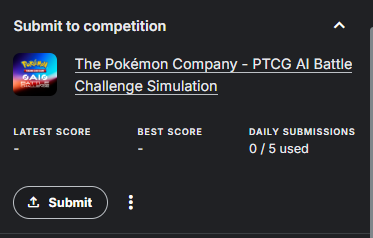

This is the quickest way to submit.

However, this is a real competition submission.  
The UI shows the daily submission count, such as `0 / 5 used`.

When you click **Submit**, Kaggle opens a confirmation dialog.

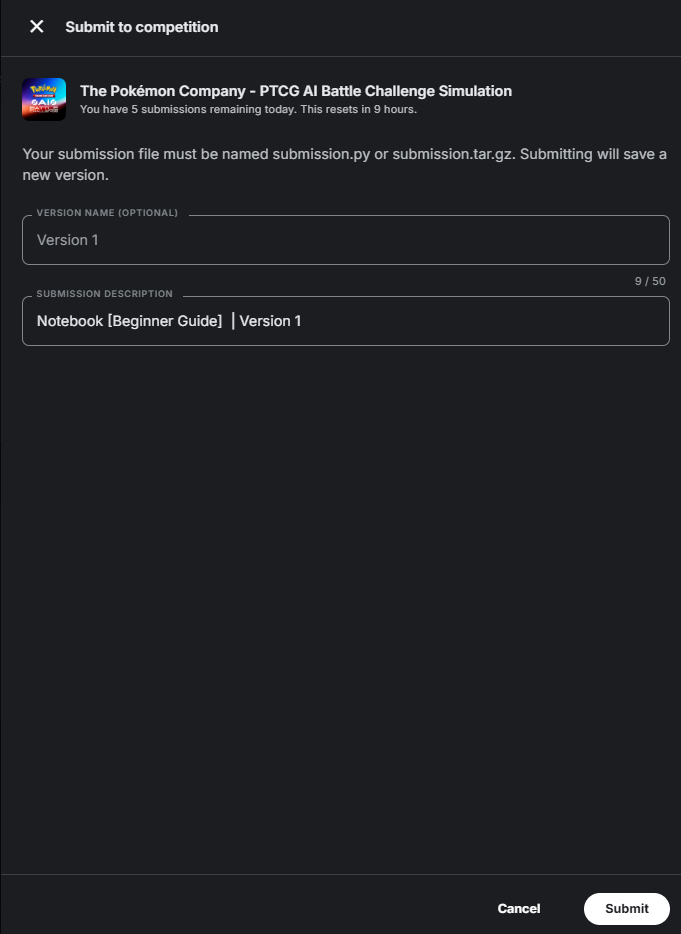

This dialog says that submitting will save a new version.

This method is convenient after your notebook is already stable.  
For your first attempt, I recommend using Method 2 below so that you can first confirm that the notebook runs successfully and that `submission.tar.gz` is created.

## Submission method 2: Save Version → check Output → Submit

For beginners, I recommend this workflow.

This method has one extra step, but it is easier to debug because you first run the whole notebook and check the output before submitting.

### Step 1: Click Save Version

Click **Save Version** in the top-right corner of the Notebook editor.

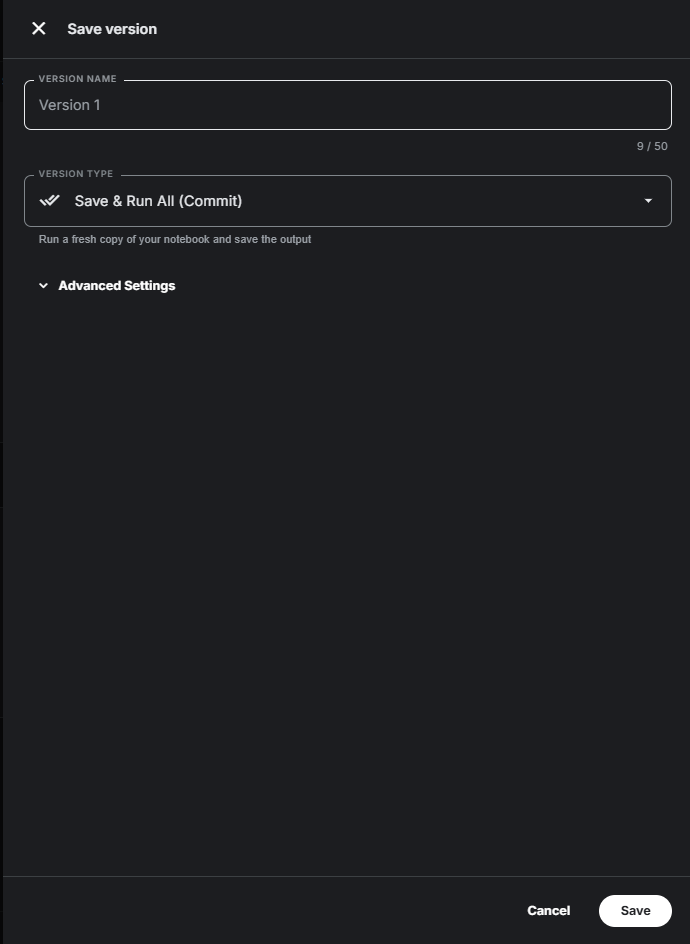

Choose **Save & Run All (Commit)**.

This runs the notebook from top to bottom in a fresh session and saves the output.

---

### Step 2: Wait until the version finishes

After the run finishes, open the version history from the top-right area.

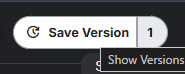

You should see a saved version such as **Version 1**.

---

### Step 3: Open the completed version

Open the saved version in Viewer.

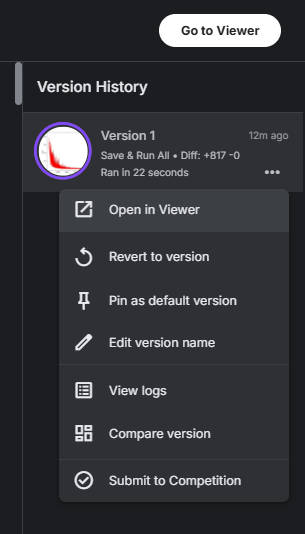

You can also see options such as **View logs** and **Submit to Competition** from the version menu.

If the notebook failed, check **View logs** first instead of submitting.

---

### Step 4: Check the Output tab

In the Viewer, open the **Output** tab.

Confirm that `submission.tar.gz` was created.

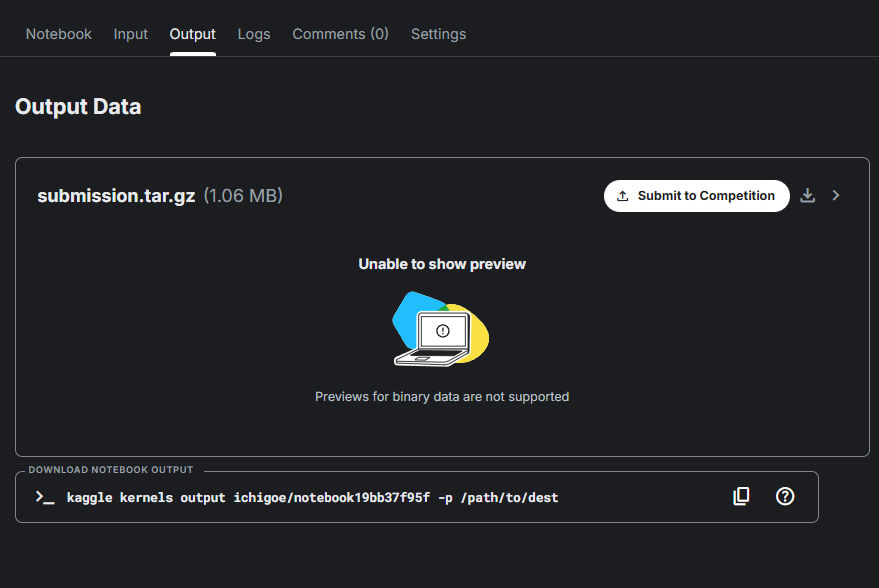

Then click **Submit to Competition** next to `submission.tar.gz`.

This is the safer workflow for beginners:

1. Save Version
2. Save & Run All
3. Wait for the version to finish
4. Open the Viewer
5. Check the Output tab
6. Confirm that `submission.tar.gz` exists
7. Submit the generated archive

## Short summary

For your first valid submission, keep the workflow simple:

1. Use the hardcoded 60-card deck, or read `deck.csv` if you prefer.
2. Write `deck.csv`.
3. Write `main.py`.
4. Package `main.py`, `deck.csv`, and `cg/` into `submission.tar.gz`.
5. Check the archive contents.
6. Use **Save Version → Save & Run All** before submitting.

You do not need to understand every Kaggle Dataset detail at the beginning.

First, make a valid submission. Then improve the deck and the agent.
